# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import re

# Loading Dataset

In [2]:
df = pd.read_csv('movies.csv')

In [ ]:
df.dtype

In [ ]:
type(df)

# Data Preparation

In [3]:
# Getting a view of the top 5 rows

df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [4]:
# Checking for missing values

# Percentage
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, pct_missing))

name - 0.0%
rating - 0.010041731872717789%
genre - 0.0%
year - 0.0%
released - 0.0002608242044861763%
score - 0.0003912363067292645%
votes - 0.0003912363067292645%
director - 0.0%
writer - 0.0003912363067292645%
star - 0.00013041210224308815%
country - 0.0003912363067292645%
budget - 0.2831246739697444%
gross - 0.02464788732394366%
company - 0.002217005738132499%
runtime - 0.0005216484089723526%


In [5]:
# Number 
print("Missing Values in the Dataset:")
print(df.isnull().sum())

# General Overview of Dataset
print("\nDataset Overview:")
print(df.describe())

Missing Values in the Dataset:
name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

Dataset Overview:
              year        score         votes        budget         gross  \
count  7668.000000  7665.000000  7.665000e+03  5.497000e+03  7.479000e+03   
mean   2000.405451     6.390411  8.810850e+04  3.558988e+07  7.850054e+07   
std      11.153508     0.968842  1.633238e+05  4.145730e+07  1.657251e+08   
min    1980.000000     1.900000  7.000000e+00  3.000000e+03  3.090000e+02   
25%    1991.000000     5.800000  9.100000e+03  1.000000e+07  4.532056e+06   
50%    2000.000000     6.500000  3.300000e+04  2.050000e+07  2.020576e+07   
75%    2010.000000     7.100000  9.300000e+04  4.500000e+07  7.601669e+07   
max    2020.000000     9.300000  2.400000e+06  3.560000e+08  2.847

In [6]:
# TOO MANY missing values

# Handling missing values
# Either:
# 1. Replace NaNs with empty string or 0

# df[['rating', 'released', 'writer', 'star', 'country', 'company']] = df[['rating', 'released', 'writer', 'star', 'country', 'company']].fillna('')  
# df['score'] = df['score'].fillna(0)
# df[['score', 'votes', 'budget', 'gross', 'runtime']] = df[['score', 'votes', 'budget', 'gross', 'runtime']].fillna(0)

# Or, 2. Drop all rows that have missing values

df = df.dropna()


In [7]:
# Number 
print("Missing Values in the Dataset:")
print(df.isnull().sum())

# General Overview of Dataset
print("\nDataset Overview:")
print(df.describe())

Missing Values in the Dataset:
name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64

Dataset Overview:
              year        score         votes        budget         gross  \
count  5421.000000  5421.000000  5.421000e+03  5.421000e+03  5.421000e+03   
mean   2001.661317     6.392455  1.150661e+05  3.600917e+07  1.032297e+08   
std      10.540908     0.962730  1.844073e+05  4.157337e+07  1.873027e+08   
min    1980.000000     1.900000  1.950000e+02  6.000000e+03  3.090000e+02   
25%    1993.000000     5.800000  1.900000e+04  1.000000e+07  1.073640e+07   
50%    2002.000000     6.500000  5.200000e+04  2.180000e+07  3.686941e+07   
75%    2011.000000     7.100000  1.290000e+05  4.500000e+07  1.124625e+08   
max    2020.000000     9.300000  2.400000e+06  3.560000e+08  2.847246e+09   

           runtime  
count  5421.

In [8]:
# Data Types of Columns

df.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

In [9]:
# Converting all values to their right data type

df[['name', 'rating', 'genre', 'released', 'director', 'writer', 'star', 'country', 'company']] = df[['name', 'rating', 'genre', 'released', 'director', 'writer', 'star', 'country', 'company']].astype(str) 
df[['year', 'votes', 'budget', 'gross', 'runtime']] = df[['year', 'votes', 'budget', 'gross', 'runtime']].astype(int)
df['score'] = df['score'].astype(float)

In [10]:
# Creating correct Year column

df['year_correct'] = df['released'].str.extract(pat = '([0-9]{4})').astype(int)

In [11]:
df.dtypes

name             object
rating           object
genre            object
year              int64
released         object
score           float64
votes             int64
director         object
writer           object
star             object
country          object
budget            int64
gross             int64
company          object
runtime           int64
year_correct      int64
dtype: object

In [11]:
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7648,Bad Boys for Life,R,Action,2020,"January 17, 2020 (United States)",6.6,140000,Adil El Arbi,Peter Craig,Will Smith,United States,90000000,426505244,Columbia Pictures,124,2020
7649,Sonic the Hedgehog,PG,Action,2020,"February 14, 2020 (United States)",6.5,102000,Jeff Fowler,Pat Casey,Ben Schwartz,United States,85000000,319715683,Paramount Pictures,99,2020
7650,Dolittle,PG,Adventure,2020,"January 17, 2020 (United States)",5.6,53000,Stephen Gaghan,Stephen Gaghan,Robert Downey Jr.,United States,175000000,245487753,Universal Pictures,101,2020
7651,The Call of the Wild,PG,Adventure,2020,"February 21, 2020 (United States)",6.8,42000,Chris Sanders,Michael Green,Harrison Ford,Canada,135000000,111105497,20th Century Studios,100,2020


In [12]:
df.sort_values(by=['gross'], inplace=False, ascending=False)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5640,Tanner Hall,R,Drama,2009,"January 15, 2015 (Sweden)",5.8,3500,Francesca Gregorini,Tatiana von Fürstenberg,Rooney Mara,United States,3000000,5073,Two Prong Lesson,96,2015
2434,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4.5,1900,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000,2970,Trimark Pictures,97,1994
3681,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6.8,43000,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000,2554,Copperheart Entertainment,108,2001
272,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3.9,2300,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000,2270,Embassy Pictures,85,1982


In [ ]:
'''

# To display ALL the rows

pd.set_option('display.max_rows', None)

# To reset above

pd.reset_option('display.max_rows')

'''

In [13]:
# Removing duplicates

df = df.drop_duplicates()



In [14]:
df

# Zero duplicates

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7648,Bad Boys for Life,R,Action,2020,"January 17, 2020 (United States)",6.6,140000,Adil El Arbi,Peter Craig,Will Smith,United States,90000000,426505244,Columbia Pictures,124,2020
7649,Sonic the Hedgehog,PG,Action,2020,"February 14, 2020 (United States)",6.5,102000,Jeff Fowler,Pat Casey,Ben Schwartz,United States,85000000,319715683,Paramount Pictures,99,2020
7650,Dolittle,PG,Adventure,2020,"January 17, 2020 (United States)",5.6,53000,Stephen Gaghan,Stephen Gaghan,Robert Downey Jr.,United States,175000000,245487753,Universal Pictures,101,2020
7651,The Call of the Wild,PG,Adventure,2020,"February 21, 2020 (United States)",6.8,42000,Chris Sanders,Michael Green,Harrison Ford,Canada,135000000,111105497,20th Century Studios,100,2020


# Data Exploration and Visualisation

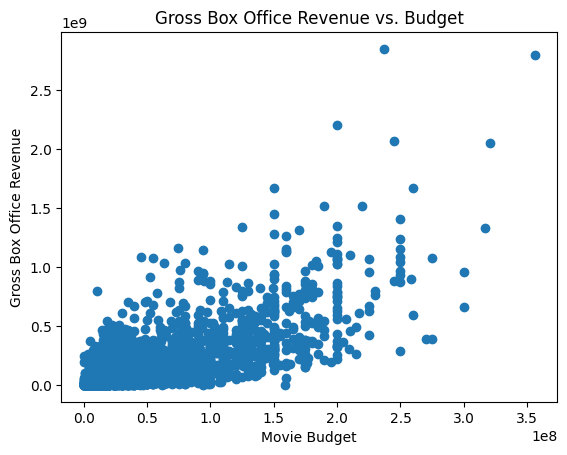

In [15]:
# Scatter Plot - Gross Box Office Revenue vs Budget

plt.scatter(x=df['budget'], y=df['gross'])
plt.title("Gross Box Office Revenue vs. Budget")
plt.xlabel("Movie Budget")
plt.ylabel("Gross Box Office Revenue")

plt.show()

In [16]:
df = df.sort_values(by=['gross'], inplace=False, ascending=False)
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149,2018


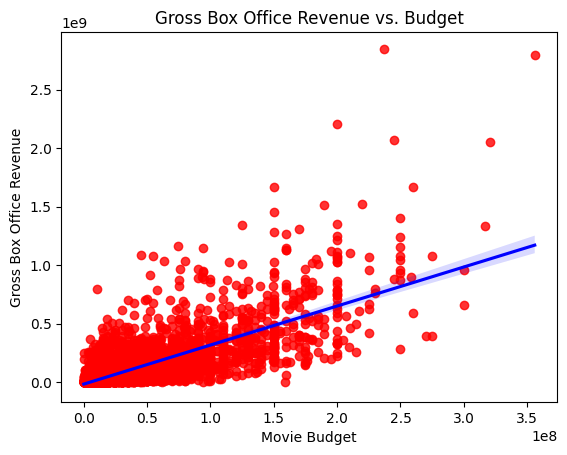

In [17]:
# Linear Regression Model Fit - Gross Box Office Revenue vs Budget

sns.regplot(x='budget', y='gross', data=df, scatter_kws={"color": "red"}, line_kws={"color": "blue"})

plt.title("Gross Box Office Revenue vs. Budget")
plt.xlabel("Movie Budget")
plt.ylabel("Gross Box Office Revenue")

plt.show()


In [18]:
# Calculating Correlation

# Pearson correlation coefficient

# df.corr(method="pearson")     # Error because there are non-numeric values
# OR
# df.corr()   # Pearson by default

df.corr(numeric_only=True) 

,year,score,votes,budget,gross,runtime,year_correct
year,1.000000,0.056386,0.206021,0.327722,0.274321,0.075077,0.998726
score,0.056386,1.000000,0.474256,0.072001,0.222556,0.414068,0.061923
votes,0.206021,0.474256,1.000000,0.439675,0.614751,0.352303,0.203098
budget,0.327722,0.072001,0.439675,1.000000,0.740247,0.318695,0.320312
gross,0.274321,0.222556,0.614751,0.740247,1.000000,0.275796,0.268721
runtime,0.075077,0.414068,0.352303,0.318695,0.275796,1.000000,0.075294
year_correct,0.998726,0.061923,0.203098,0.320312,0.268721,0.075294,1.000000


In [19]:
# Spearman correlation coefficient

df.corr(method="spearman", numeric_only=True)

,year,score,votes,budget,gross,runtime,year_correct
year,1.000000,0.057741,0.427623,0.312886,0.351045,0.095444,0.998694
score,0.057741,1.000000,0.495409,-0.009971,0.183192,0.412155,0.063674
votes,0.427623,0.495409,1.000000,0.493461,0.745793,0.300621,0.422988
budget,0.312886,-0.009971,0.493461,1.000000,0.692958,0.330794,0.302535
gross,0.351045,0.183192,0.745793,0.692958,1.000000,0.257400,0.340529
runtime,0.095444,0.412155,0.300621,0.330794,0.257400,1.000000,0.095507
year_correct,0.998694,0.063674,0.422988,0.302535,0.340529,0.095507,1.000000


In [20]:
# Kendall correlation coefficient

df.corr(method="kendall", numeric_only=True)

,year,score,votes,budget,gross,runtime,year_correct
year,1.000000,0.039389,0.296512,0.220833,0.239539,0.064824,0.991304
score,0.039389,1.000000,0.350185,-0.006406,0.124943,0.292254,0.043400
votes,0.296512,0.350185,1.000000,0.346274,0.553625,0.205344,0.293044
budget,0.220833,-0.006406,0.346274,1.000000,0.512057,0.231278,0.213719
gross,0.239539,0.124943,0.553625,0.512057,1.000000,0.176979,0.232372
runtime,0.064824,0.292254,0.205344,0.231278,0.176979,1.000000,0.064793
year_correct,0.991304,0.043400,0.293044,0.213719,0.232372,0.064793,1.000000


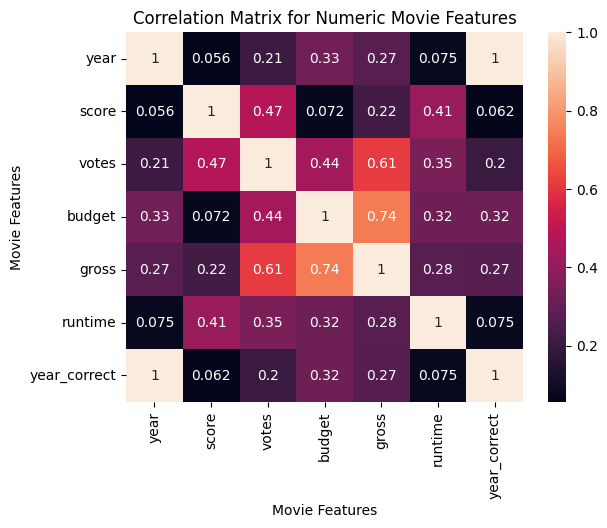

In [21]:
# Correlation Matrix Visualisation - Numeric Movie Features

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True)

plt.title("Correlation Matrix for Numeric Movie Features")
plt.xlabel("Movie Features")
plt.ylabel("Movie Features")

plt.show()

In [22]:
# Looking for the numeric features that correlate mostly with Gross Box Office Revenue

# Numeric columns

df.corr(numeric_only=True)['gross'].sort_values(ascending=False)

gross           1.000000
budget          0.740247
votes           0.614751
runtime         0.275796
year            0.274321
year_correct    0.268721
score           0.222556
Name: gross, dtype: float64

In [23]:
# Now dealing with non-numeric features

# Unique Ratings

df_rating = df['rating'].drop_duplicates().sort_values(ascending=False)

df_rating

1065            X
886       Unrated
7565        TV-MA
7450            R
5445        PG-13
7480           PG
7652    Not Rated
5112        NC-17
2448            G
120      Approved
Name: rating, dtype: object

In [ ]:
# 2. For rating specifically — manually impose the logical order
rating_order = {'G': 1, 'PG': 2, 'PG-13': 3, 'R': 4, 'NC-17': 5}
df['rating_encoded'] = df['rating'].map(rating_order)

# 3. Factorize genre/country for a rough signal — treat results loosely
import pandas as pd
for col in ['genre', 'country', 'company']:
    df[col + '_encoded'] = pd.factorize(df[col])[0]

In [29]:
# Mean gross per company

company_avg_gross = df.groupby('company')['gross'].transform('mean')
df['company_avg_gross'] = company_avg_gross

print(df[['company_avg_gross', 'gross']].corr())


# Mean gross per director

director_avg_gross = df.groupby('director')['gross'].transform('mean')
df['director_avg_gross'] = director_avg_gross

print(df[['director_avg_gross', 'gross']].corr())


# Mean gross per star

star_avg_gross = df.groupby('star')['gross'].transform('mean')
df['star_avg_gross'] = star_avg_gross

print(df[['star_avg_gross', 'gross']].corr())

                   company_avg_gross     gross
company_avg_gross           1.000000  0.596763
gross                       0.596763  1.000000
                    director_avg_gross     gross
director_avg_gross            1.000000  0.730141
gross                         0.730141  1.000000
                star_avg_gross     gross
star_avg_gross        1.000000  0.643848
gross                 0.643848  1.000000


In [ ]:
# Converting all non-numeric columns to numeric

df_numeric = df

'''for col in df_numeric.columns:
    if df_numeric[col].dtype == 'object':
        df_numeric[col] = pd.factorize(df_numeric[col])[0]
'''

# OR 

# df_numeric = df_numeric.apply(lambda x: pd.factorize(x)[0] if x.dtype == 'object' else x))


for col in df_numeric.columns:
    if df_numeric[col].dtype == 'object':
        df_numeric[col] = df_numeric[col].astype('category')
        df_numeric[col] = df_numeric[col].cat.codes

# OR

# df_numeric = df_numeric.apply(lambda x: x.astype('category').cat.codes if x.dtype == 'object' else x)

df_numeric

df_numeric.corr()

'''
OR

df_numeric.corr(method="spearman")
df_numeric.corr(method="kendall")

'''

# Correlation Matrix Visualisation

correlation_matrix = df_numeric.corr()

sns.heatmap(correlation_matrix, annot=True)

plt.title("Correlation Matrix for Movie Features")
plt.xlabel("Movie Features")
plt.ylabel("Movie Features")

plt.show()